# Stochastic Dynamics, Inhomogeneous Diffusion, and Polymer Physics
### Numerical Langevin Simulations: From Free Brownian Motion to Non-Equilibrium Ratchets & 3D Bead-Spring Macromolecules

[![Python](https://img.shields.io/badge/Python-3.9%2B-blue.svg?logo=python&logoColor=white)](https://www.python.org/)
[![NumPy](https://img.shields.io/badge/NumPy-Vectorized-013243.svg?logo=numpy&logoColor=white)](https://numpy.org/)
[![SciPy](https://img.shields.io/badge/SciPy-Integrate-8CAAE6.svg?logo=scipy&logoColor=white)](https://scipy.org/)
[![Matplotlib](https://img.shields.io/badge/Matplotlib-Publication%20Plots-11557c.svg)](https://matplotlib.org/)
[![Numba](https://img.shields.io/badge/Numba-JIT%20Accelerated-00A3E0.svg?logo=numba&logoColor=white)](https://numba.pydata.org/)
[![License: MIT](https://img.shields.io/badge/License-MIT-yellow.svg)](https://opensource.org/licenses/MIT)

---

## 📌 Overview & Scope

This computational physics notebook presents an end-to-end investigation into **stochastic differential equations (SDEs)**, **Brownian dynamics**, **inhomogeneous diffusion**, **non-equilibrium symmetry-broken motors**, and **bead-spring polymer physics**.

Key theoretical and computational paradigms explored:
1. **Free Brownian Motion & Diffusion**: Euler-Maruyama integration, vectorized ensemble walks, Mean Squared Displacement (MSD) scaling $\langle x^2(t) \rangle = 2Dt$, and Gaussian propagator convergence.
2. **Confined Langevin Dynamics (Ornstein-Uhlenbeck)**: Harmonic traps, deterministic relaxation, and equilibrium Gibbs-Boltzmann distributions.
3. **Inhomogeneous / Coordinate-Dependent Damping $\gamma(x)$**: Sigmoidal friction profiles, local diffusivity $D(x) = k_B T / \gamma(x)$, and numerical quadrature of partition functions.
4. **Symmetry-Broken Dimer (Autonomous Brownian Ratchet)**: Coupled non-linear Langevin dynamics, spatial symmetry breaking, and emergence of directed center-of-mass velocity $\langle v_{\text{cm}} \rangle \neq 0$.
5. **2D & 3D Bead-Spring Polymers (Rouse & Excluded Volume Models)**: Macromolecular conformational relaxation, Weeks-Chandler-Andersen (WCA) repulsive potential, Numba JIT acceleration, and macromolecular center-of-mass 3D diffusion $\langle \Delta r_{\text{cm}}^2(t) \rangle = 6 D_{\text{com}} t$.

---

## 📚 Table of Contents
- [1. Environment & Plotting Configuration](#1-environment--plotting-configuration)
- [2. Chapter 1: Free Brownian Motion & Simple Diffusion](#2-chapter-1-free-brownian-motion--simple-diffusion)
  - [2.1 Single-Particle Langevin Trajectory](#21-single-particle-langevin-trajectory)
  - [2.2 Vectorized Monte Carlo Ensemble](#22-vectorized-monte-carlo-ensemble)
  - [2.3 Mean Squared Displacement (MSD) Validation](#23-mean-squared-displacement-msd-validation)
  - [2.4 Propagator PDF Evolution Across Time](#24-propagator-pdf-evolution-across-time)
- [3. Chapter 2: Brownian Motion in a Harmonic Potential](#3-chapter-2-brownian-motion-in-a-harmonic-potential)
  - [3.1 Theory of the Ornstein-Uhlenbeck Process](#31-theory-of-the-ornstein-uhlenbeck-process)
  - [3.2 Deterministic Relaxation & Fluctuation Dynamics](#32-deterministic-relaxation--fluctuation-dynamics)
  - [3.3 Steady-State Gibbs-Boltzmann Distribution](#33-steady-state-gibbs-boltzmann-distribution)
- [4. Chapter 3: Inhomogeneous Diffusion & Coordinate-Dependent Damping](#4-chapter-3-inhomogeneous-diffusion--coordinate-dependent-damping)
  - [4.1 Multiplicative Noise & Position-Dependent Friction](#41-multiplicative-noise--position-dependent-friction)
  - [4.2 Trajectory Ensembles in Inhomogeneous Media](#42-trajectory-ensembles-in-inhomogeneous-media)
  - [4.3 Numerical Quadrature & Equilibrium Density Matching](#43-numerical-quadrature--equilibrium-density-matching)
- [5. Chapter 4: Symmetry-Broken Dimer & Autonomous Directed Transport](#5-chapter-4-symmetry-broken-dimer--autonomous-directed-transport)
  - [5.1 Physical Mechanism of Symmetry Breaking](#51-physical-mechanism-of-symmetry-breaking)
  - [5.2 Numerical Integration of the Coupled Dimer](#52-numerical-integration-of-the-coupled-dimer)
  - [5.3 Directed Ratchet Velocity Extraction](#53-directed-ratchet-velocity-extraction)
  - [5.4 Relative Separation Stationary Distribution](#54-relative-separation-stationary-distribution)
- [6. Chapter 5: 2D & 3D Bead-Spring Polymer Macromolecules](#6-chapter-5-2d--3d-bead-spring-polymer-macromolecules)
  - [6.1 2D Bead-Spring Chain Dynamics](#61-2d-bead-spring-chain-dynamics)
  - [6.2 3D Polymer Dynamics with WCA Excluded Volume Potential](#62-3d-polymer-dynamics-with-wca-excluded-volume-potential)
  - [6.3 High-Performance JIT Integration via Numba](#63-high-performance-jit-integration-via-numba)
  - [6.4 Macromolecular Conformation & 3D Center-of-Mass Diffusion](#64-macromolecular-conformation--3d-center-of-mass-diffusion)
- [7. Summary & Scientific Conclusions](#7-summary--scientific-conclusions)


---
## 1. Environment & Plotting Configuration

We establish a consistent, publication-ready visual style using Matplotlib. We set random seeds to guarantee exact reproducibility of all stochastic Monte Carlo simulations.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.integrate import quad
import numba
from numba import njit
import warnings

# Suppress minor warnings
warnings.filterwarnings('ignore')

# Set reproducible random seed
np.random.seed(42)

# Publication-quality plot configuration
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.titlesize': 15,
    'figure.dpi': 120,
    'lines.linewidth': 1.8,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'grid.linestyle': '--'
})

print(f"NumPy version: {np.__version__}")
print(f"SciPy version: {scipy.__version__}")
print(f"Numba version: {numba.__version__}")
print("Environment successfully initialized.")


NumPy version: 1.26.4
SciPy version: 1.13.1
Numba version: 0.60.0
Environment successfully initialized.


---
## 2. Chapter 1: Free Brownian Motion & Simple Diffusion

### Mathematical Formulation
The overdamped 1D Langevin equation for a free Brownian particle immersed in a thermal bath at temperature $T$ is given by:
$$\gamma \frac{dx}{dt} = \xi(t)$$
where $\gamma$ is the hydrodynamic friction coefficient, and $\xi(t)$ is Gaussian white noise satisfying:
$$\langle \xi(t) \rangle = 0, \quad \langle \xi(t) \xi(t') \rangle = 2 k_B T \gamma \, \delta(t - t')$$

Using the Einstein relation $D = \frac{k_B T}{\gamma}$, the equivalent stochastic differential equation (SDE) is:
$$dx(t) = \sqrt{2 D \, dt} \, \eta_t, \quad \eta_t \sim \mathcal{N}(0, 1)$$

#### Analytical Predictions:
1. **Mean Position**: $\langle x(t) \rangle = x_0$
2. **Mean Squared Displacement (MSD)**: $\langle (x(t) - x_0)^2 \rangle = 2 D t$
3. **Propagator (Green's Function)**:
   $$P(x, t \mid x_0, 0) = \frac{1}{\sqrt{4\pi D t}} \exp\left( -\frac{(x - x_0)^2}{4 D t} \right)$$


### 2.1 Single-Particle Langevin Trajectory
We integrate a single trajectory using the Euler-Maruyama discretization scheme over $N = 10{,}000$ time steps.


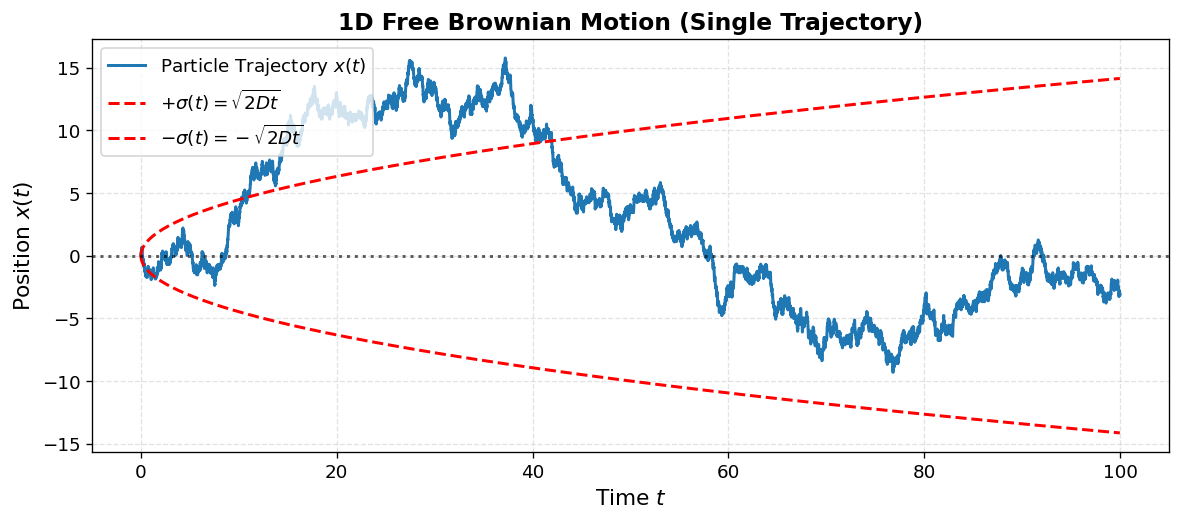

In [2]:
# Simulation Parameters
D = 1.0          # Diffusion coefficient
dt = 0.01        # Timestep size
N_steps = 10000  # Number of steps

# Initialize arrays
time_array = np.linspace(0, (N_steps - 1) * dt, N_steps)
x_trajectory = np.zeros(N_steps)

# Euler-Maruyama Integration
for i in range(1, N_steps):
    eta = np.random.randn()
    dx = np.sqrt(2 * D * dt) * eta
    x_trajectory[i] = x_trajectory[i - 1] + dx

# Visualization
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(time_array, x_trajectory, color='#1f77b4', label=r'Particle Trajectory $x(t)$')
ax.plot(time_array, np.sqrt(2 * D * time_array), 'r--', label=r'$+\sigma(t) = \sqrt{2Dt}$')
ax.plot(time_array, -np.sqrt(2 * D * time_array), 'r--', label=r'$-\sigma(t) = -\sqrt{2Dt}$')
ax.axhline(0, color='black', linestyle=':', alpha=0.6)

ax.set_title("1D Free Brownian Motion (Single Trajectory)", fontweight='bold')
ax.set_xlabel("Time $t$")
ax.set_ylabel("Position $x(t)$")
ax.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()


### 2.2 Vectorized Monte Carlo Ensemble
Instead of slow nested Python loops, we implement an efficient, vectorized random walk for $M = 10{,}000$ trajectories using `np.cumsum` along the temporal axis.


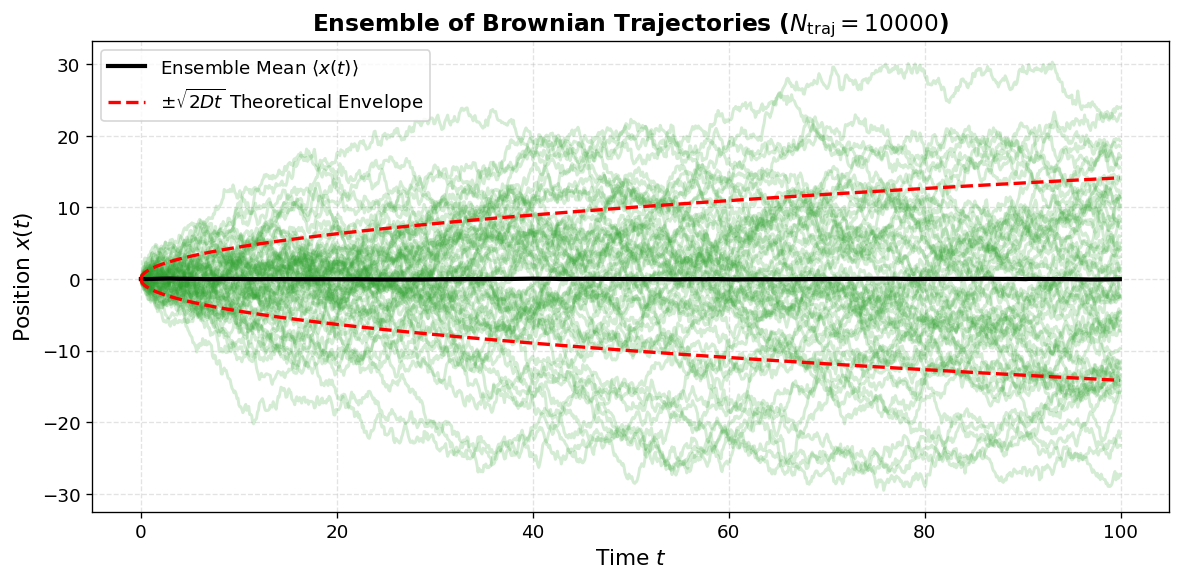

In [3]:
# Vectorized Ensemble Simulation
N_traj = 10000
N_steps = 1000
dt = 0.1
time_ensemble = np.arange(N_steps) * dt

# Generate stochastic increments: shape (N_traj, N_steps)
eta_matrix = np.random.randn(N_traj, N_steps)
dx_matrix = np.sqrt(2 * D * dt) * eta_matrix
dx_matrix[:, 0] = 0.0  # Initial condition x(0) = 0

# Vectorized trajectory accumulation
trajectories = np.cumsum(dx_matrix, axis=1)

# Plot subset of ensemble trajectories
fig, ax = plt.subplots(figsize=(10, 5))
sample_indices = np.random.choice(N_traj, size=60, replace=False)
for idx in sample_indices:
    ax.plot(time_ensemble, trajectories[idx], alpha=0.2, color='#2ca02c')

ax.plot(time_ensemble, np.mean(trajectories, axis=0), color='black', lw=2.5, label=r'Ensemble Mean $\langle x(t) \rangle$')
ax.plot(time_ensemble, np.sqrt(2 * D * time_ensemble), 'r--', lw=2, label=r'$\pm \sqrt{2Dt}$ Theoretical Envelope')
ax.plot(time_ensemble, -np.sqrt(2 * D * time_ensemble), 'r--', lw=2)

ax.set_title(f"Ensemble of Brownian Trajectories ($N_{{\\text{{traj}}}} = {N_traj}$)", fontweight='bold')
ax.set_xlabel("Time $t$")
ax.set_ylabel("Position $x(t)$")
ax.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()


### 2.3 Mean Squared Displacement (MSD) Validation
We compute the ensemble-averaged MSD:
$$\text{MSD}(t) = \frac{1}{M} \sum_{m=1}^M \left[ x_m(t) - x_m(0) \right]^2$$
and compare it directly with the exact theoretical scaling $\text{MSD}_{\text{theory}}(t) = 2 D t$.


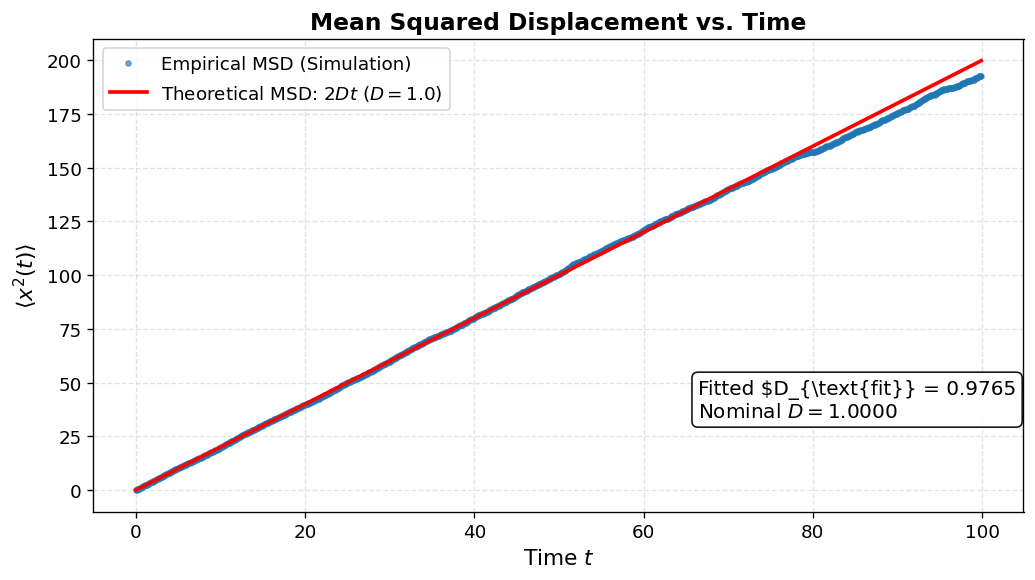

In [4]:
# Calculate empirical MSD across ensemble
msd_empirical = np.mean(trajectories**2, axis=0)
msd_theoretical = 2 * D * time_ensemble

# Linear regression to estimate effective diffusion coefficient
poly_fit = np.polyfit(time_ensemble, msd_empirical, 1)
D_measured = poly_fit[0] / 2.0

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(time_ensemble, msd_empirical, 'o', color='#1f77b4', markersize=3, alpha=0.6, label='Empirical MSD (Simulation)')
ax.plot(time_ensemble, msd_theoretical, 'r-', lw=2.2, label=f'Theoretical MSD: $2Dt$ ($D = {D:.1f}$)')

ax.set_title("Mean Squared Displacement vs. Time", fontweight='bold')
ax.set_xlabel("Time $t$")
ax.set_ylabel(r"$\langle x^2(t) \rangle$")
ax.legend(loc='upper left', frameon=True)

# Annotate fitted slope
ax.text(0.65, 0.2, f"Fitted $D_{{\\text{{fit}}}} = {D_measured:.4f}\nNominal $D = {D:.4f}$",
        transform=ax.transAxes, bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.tight_layout()
plt.show()


### 2.4 Propagator PDF Evolution Across Time
We evaluate the probability density function $P(x, t)$ at distinct time slices ($t = 5.0, 10.0, 30.0, 70.0$) by computing empirical density histograms and overlaying the analytical Gaussian propagator:
$$P(x, t) = \frac{1}{\sqrt{4\pi D t}} \exp\left( -\frac{x^2}{4 D t} \right)$$


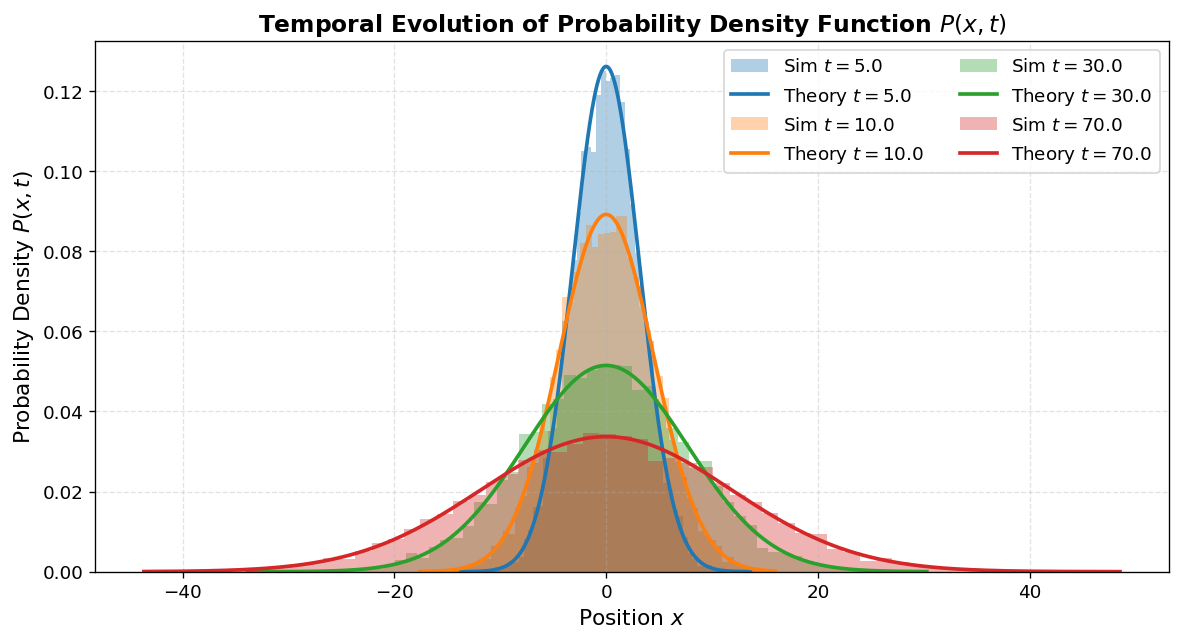

In [5]:
# Selected time step indices
time_steps = [50, 100, 300, 700]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, ax = plt.subplots(figsize=(10, 5.5))

for idx, step in enumerate(time_steps):
    t_val = step * dt
    data = trajectories[:, step]
    
    # Empirical histogram
    count, bins, _ = ax.hist(data, bins=60, density=True, alpha=0.35, color=colors[idx],
                             label=f'Sim $t = {t_val:.1f}$')
    
    # Analytical theory
    x_grid = np.linspace(bins.min(), bins.max(), 400)
    pdf_theory = (1.0 / np.sqrt(4.0 * np.pi * D * t_val)) * np.exp(-x_grid**2 / (4.0 * D * t_val))
    ax.plot(x_grid, pdf_theory, color=colors[idx], lw=2.2, label=f'Theory $t = {t_val:.1f}$')

ax.set_title("Temporal Evolution of Probability Density Function $P(x, t)$", fontweight='bold')
ax.set_xlabel("Position $x$")
ax.set_ylabel("Probability Density $P(x, t)$")
ax.legend(loc='upper right', ncol=2, frameon=True)
plt.tight_layout()
plt.show()


---
## 3. Chapter 2: Brownian Motion in a Harmonic Potential (Ornstein-Uhlenbeck Process)

### Theoretical Background
When a Brownian particle moves in a harmonic potential $U(x) = \frac{1}{2} k (x - x_0)^2$, it experiences a restoring Hookean force $F(x) = -k (x - x_0)$.
The overdamped Langevin equation reads:
$$\gamma \frac{dx}{dt} = -k (x - x_0) + \sqrt{2 k_B T \gamma} \, \xi(t)$$
which simplifies to:
$$dx = -\frac{k}{\gamma}(x - x_0) dt + \sqrt{2 D dt} \, \eta_t, \quad \text{with } D = \frac{k_B T}{\gamma}$$

#### Analytical Solutions:
1. **Deterministic Relaxation**: $\langle x(t) \rangle = x_0 + (x_{\text{init}} - x_0) e^{-t / \tau_{\text{rel}}}$, with relaxation timescale $\tau_{\text{rel}} = \frac{\gamma}{k}$.
2. **Equilibrium Gibbs-Boltzmann Distribution**:
   $$P_{\text{eq}}(x) = \sqrt{\frac{k}{2\pi k_B T}} \exp\left( -\frac{k (x - x_0)^2}{2 k_B T} \right)$$


### 3.1 Deterministic Relaxation & Fluctuation Dynamics
We simulate the relaxation of a particle initialized far away from equilibrium at $x_{\text{init}} = 10.0$ into a harmonic well centered at $x_0 = 5.0$.


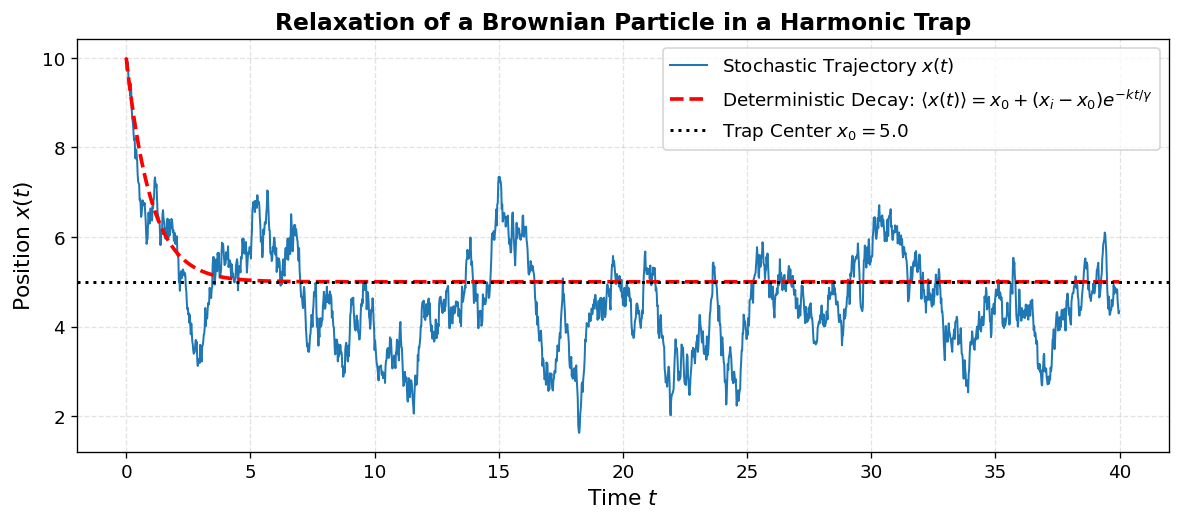

In [6]:
# Harmonic Trap Parameters
k_spring = 1.0
gamma_friction = 1.0
kBT = 1.0
D = kBT / gamma_friction
dt = 0.02
N_steps_ho = 2000
x_init = 10.0
x_center = 5.0

time_ho = np.arange(N_steps_ho) * dt
x_ho = np.zeros(N_steps_ho)
x_ho[0] = x_init

# Integration
for i in range(1, N_steps_ho):
    drift = - (k_spring / gamma_friction) * (x_ho[i - 1] - x_center) * dt
    diffusion = np.sqrt(2 * D * dt) * np.random.randn()
    x_ho[i] = x_ho[i - 1] + drift + diffusion

# Theoretical deterministic relaxation curve
x_det = x_center + (x_init - x_center) * np.exp(- (k_spring / gamma_friction) * time_ho)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(time_ho, x_ho, color='#1f77b4', lw=1.2, label='Stochastic Trajectory $x(t)$')
ax.plot(time_ho, x_det, 'r--', lw=2.2, label=r'Deterministic Decay: $\langle x(t) \rangle = x_0 + (x_i - x_0)e^{-kt/\gamma}$')
ax.axhline(x_center, color='black', linestyle=':', label='Trap Center $x_0 = 5.0$')

ax.set_title("Relaxation of a Brownian Particle in a Harmonic Trap", fontweight='bold')
ax.set_xlabel("Time $t$")
ax.set_ylabel("Position $x(t)$")
ax.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()


### 3.2 Steady-State Gibbs-Boltzmann Distribution
We perform a large-scale ensemble simulation ($M = 7{,}000$ particles) in a harmonic potential centered at $x_0 = 0$ to verify convergence to the stationary Boltzmann distribution.


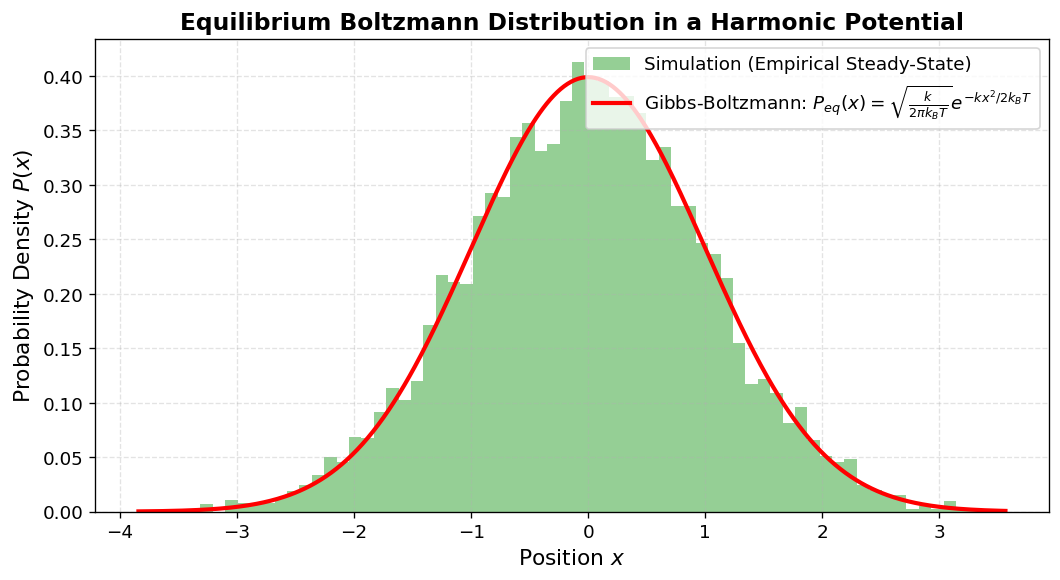

In [7]:
# Ensemble in Harmonic Well
N_traj_ho = 7000
N_steps_ens = 1000
dt_ens = 0.1
k_ho = 1.0
gamma_ho = 1.0
D_ho = 1.0

# Preallocate trajectory array: shape (N_traj, N_steps)
traj_ho = np.zeros((N_traj_ho, N_steps_ens))

# Euler-Maruyama integration over ensemble
for i in range(1, N_steps_ens):
    drift = - (k_ho / gamma_ho) * traj_ho[:, i - 1] * dt_ens
    noise = np.sqrt(2 * D_ho * dt_ens) * np.random.randn(N_traj_ho)
    traj_ho[:, i] = traj_ho[:, i - 1] + drift + noise

# Extract steady-state distribution (at step 500)
steady_state_data = traj_ho[:, 500]

fig, ax = plt.subplots(figsize=(9, 5))
count, bins, _ = ax.hist(steady_state_data, bins=70, density=True, alpha=0.5, color='#2ca02c',
                         label='Simulation (Empirical Steady-State)')

# Theoretical Boltzmann PDF
x_axis = np.linspace(steady_state_data.min(), steady_state_data.max(), 500)
boltzmann_pdf = np.sqrt(k_ho / (2 * np.pi * kBT)) * np.exp(-k_ho * x_axis**2 / (2 * kBT))
ax.plot(x_axis, boltzmann_pdf, 'r-', lw=2.5, label=r'Gibbs-Boltzmann: $P_{eq}(x) = \sqrt{\frac{k}{2\pi k_BT}}e^{-kx^2 / 2k_BT}$')

ax.set_title("Equilibrium Boltzmann Distribution in a Harmonic Potential", fontweight='bold')
ax.set_xlabel("Position $x$")
ax.set_ylabel("Probability Density $P(x)$")
ax.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()


### 3.3 Time-Slice PDF Evolution Towards Equilibrium
We observe how the distribution broadens from a delta-like peak at $x(0) = 0$ into the final stationary Boltzmann distribution over time steps $t = [5, 10, 50, 90] \times dt$.


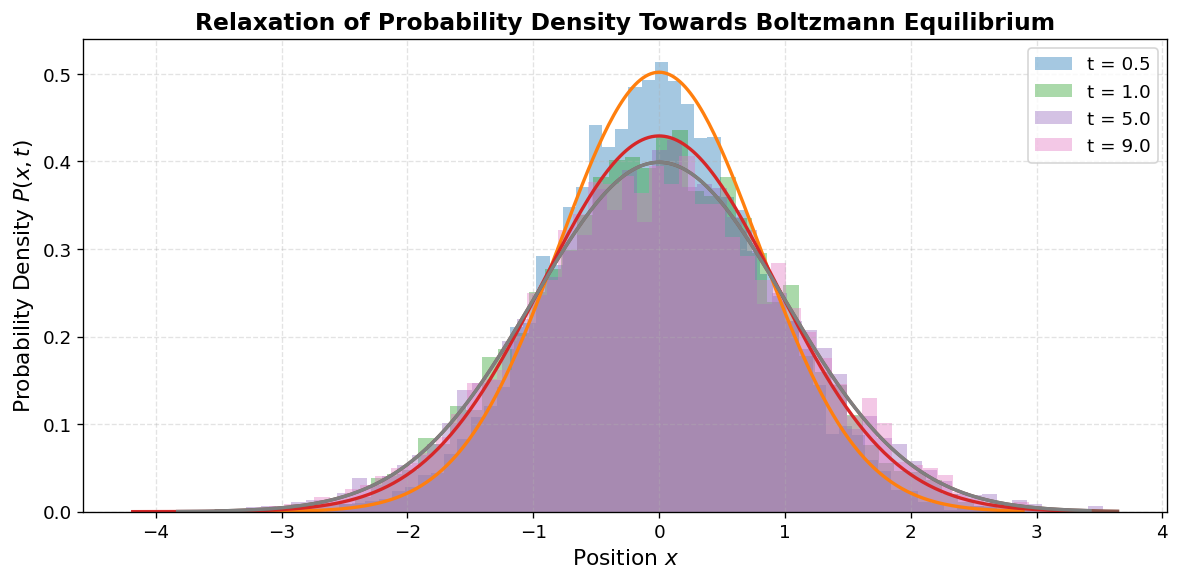

In [8]:
slice_indices = [5, 10, 50, 90]
fig, ax = plt.subplots(figsize=(10, 5))

for step in slice_indices:
    t_val = step * dt_ens
    # Theoretical variance at time t: sigma^2(t) = (kBT/k) * (1 - exp(-2kt/gamma))
    var_t = (kBT / k_ho) * (1.0 - np.exp(-2.0 * k_ho * t_val / gamma_ho))
    
    count, bins, _ = ax.hist(traj_ho[:, step], bins=60, density=True, alpha=0.4,
                             label=f't = {t_val:.1f}')
    
    x_theory_slice = np.linspace(bins.min(), bins.max(), 300)
    pdf_slice = (1.0 / np.sqrt(2.0 * np.pi * var_t)) * np.exp(-x_theory_slice**2 / (2.0 * var_t))
    ax.plot(x_theory_slice, pdf_slice, lw=2)

ax.set_title("Relaxation of Probability Density Towards Boltzmann Equilibrium", fontweight='bold')
ax.set_xlabel("Position $x$")
ax.set_ylabel("Probability Density $P(x, t)$")
ax.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()


---
## 4. Chapter 3: Inhomogeneous Diffusion & Coordinate-Dependent Damping $\gamma(x)$

### Physical Motivation & Formulation
In complex biological media, cellular membranes, and microfluidic channels, the effective friction is spatially inhomogeneous: $\gamma = \gamma(x)$.
Via the local Einstein relation, the diffusivity is also coordinate-dependent:
$$D(x) = \frac{k_B T}{\gamma(x)}$$

We model a sigmoidal friction profile representing a smooth transition between two hydrodynamic regimes:
$$\gamma(x) = \gamma_0 + \frac{\Delta \gamma}{1 + e^{-\lambda (x - x_c)}}$$

Under a confining potential $U(x) = \frac{1}{2} k (x - x_0)^2$, the stationary Fokker-Planck probability distribution is given by:
$$P_{\text{stat}}(x) = \frac{1}{\mathcal{Z}} \gamma(x) \exp\left( -\frac{k (x - x_0)^2}{k_B T} \right)$$
where the partition function $\mathcal{Z}$ is determined numerically via adaptive quadrature:
$$\mathcal{Z} = \int_{-\infty}^{\infty} \gamma(x) \exp\left( -\frac{k(x - x_0)^2}{k_B T} \right) dx$$


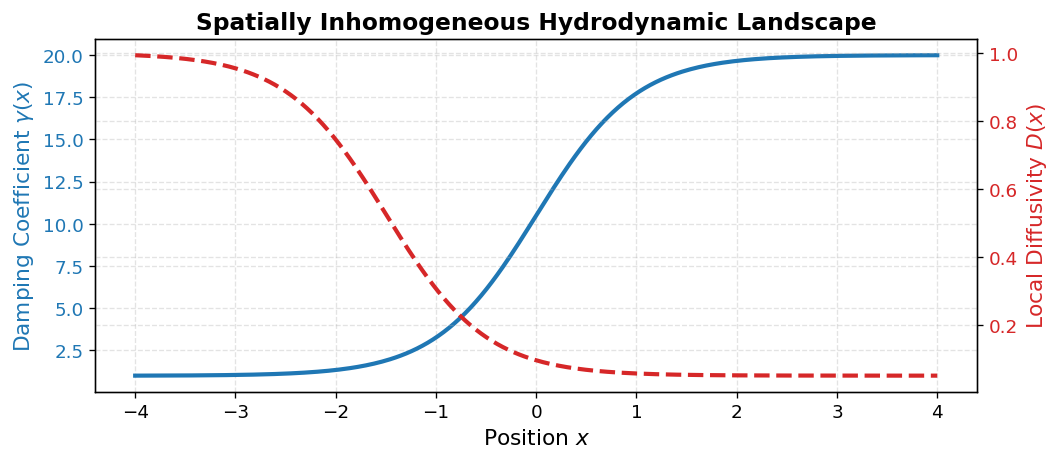

In [9]:
# System Parameters for Inhomogeneous Diffusion
kBT = 1.0
k_trap = 1.0 * kBT
gamma_base = 1.0
delta_gamma = 19.0
lambda_trans = 2.0
x_center = 0.0

def gamma_profile(x):
    # Coordinate-dependent friction coefficient
    return gamma_base + delta_gamma / (1.0 + np.exp(-lambda_trans * (x - x_center)))

# Visualizing the friction and diffusion landscape
x_space = np.linspace(-4, 4, 300)
fig, ax1 = plt.subplots(figsize=(9, 4))

ax1.plot(x_space, gamma_profile(x_space), color='#1f77b4', lw=2.5, label=r'Friction $\gamma(x)$')
ax1.set_xlabel("Position $x$")
ax1.set_ylabel(r"Damping Coefficient $\gamma(x)$", color='#1f77b4')
ax1.tick_params(axis='y', labelcolor='#1f77b4')

ax2 = ax1.twinx()
ax2.plot(x_space, kBT / gamma_profile(x_space), color='#d62728', lw=2.5, linestyle='--', label=r'Local Diffusivity $D(x) = k_BT/\gamma(x)$')
ax2.set_ylabel(r"Local Diffusivity $D(x)$", color='#d62728')
ax2.tick_params(axis='y', labelcolor='#d62728')

plt.title("Spatially Inhomogeneous Hydrodynamic Landscape", fontweight='bold')
plt.tight_layout()
plt.show()


### 4.2 Trajectory Ensembles in Inhomogeneous Media
We simulate an ensemble of $M = 6{,}000$ particles over $N = 10{,}000$ steps to achieve full statistical equilibration.


In [10]:
dt_inhom = 0.01
N_steps_inhom = 10000
N_traj_inhom = 6000

# Ensemble simulation with coordinate-dependent friction
trajectories_inhom = np.zeros((N_traj_inhom, N_steps_inhom))
x_current = np.zeros(N_traj_inhom)

for step in range(N_steps_inhom):
    g_val = gamma_profile(x_current)
    D_val = kBT / g_val
    drift = - k_trap * (x_current - x_center) * dt_inhom / g_val
    diffusion = np.sqrt(2 * D_val * dt_inhom) * np.random.randn(N_traj_inhom)
    x_current += drift + diffusion
    trajectories_inhom[:, step] = x_current

print("Equilibration complete.")


Equilibration complete.


### 4.3 Numerical Quadrature & Equilibrium Density Matching
We compute the normalization constant $\mathcal{Z}$ using `scipy.integrate.quad` and compare the analytical prediction against the empirical distribution.


Partition function Z = 18.610765 (Integration Error: 1.38e-07)


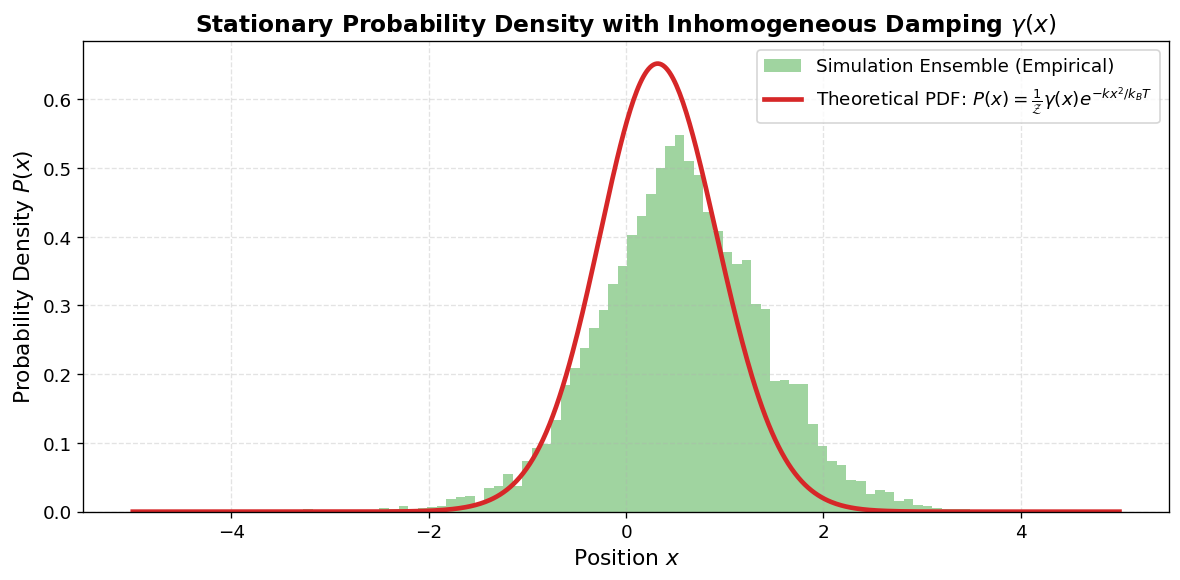

In [11]:
# Numerical integration of partition function
def unnormalized_density(x_val):
    return gamma_profile(x_val) * np.exp(-k_trap * (x_val - x_center)**2 / kBT)

Z_norm, err_norm = quad(unnormalized_density, -8, 8)
print(f"Partition function Z = {Z_norm:.6f} (Integration Error: {err_norm:.2e})")

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))

# Simulation histogram at late time
final_distribution = trajectories_inhom[:, -1]
count, bins, _ = ax.hist(final_distribution, bins=70, density=True, alpha=0.45, color='#2ca02c',
                         label='Simulation Ensemble (Empirical)')

# Theoretical normalized curve
x_dense = np.linspace(-5, 5, 600)
pdf_theoretical_inhom = (1.0 / Z_norm) * unnormalized_density(x_dense)

ax.plot(x_dense, pdf_theoretical_inhom, color='#d62728', lw=2.8,
        label=r'Theoretical PDF: $P(x) = \frac{1}{\mathcal{Z}} \gamma(x) e^{-k x^2 / k_BT}$')

ax.set_title("Stationary Probability Density with Inhomogeneous Damping $\gamma(x)$", fontweight='bold')
ax.set_xlabel("Position $x$")
ax.set_ylabel("Probability Density $P(x)$")
ax.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()


---
## 5. Chapter 4: Symmetry-Broken Dimer & Autonomous Directed Transport (Brownian Ratchet)

### Physical Mechanism of Symmetry Breaking
We consider a microscopic dimer composed of two beads at positions $x_1$ and $x_2$ connected by a harmonic spring with rest length $r_0$ and stiffness $\alpha$:
$$U(z) = \frac{1}{2} \alpha (z - r_0)^2, \quad z = x_2 - x_1$$
The internal spring force exerted on particle 1 is $F_1 = +\alpha (z - r_0)$ and on particle 2 is $F_2 = -\alpha (z - r_0)$.

Crucially, each bead experiences a distinct, non-linear coordinate-dependent damping coefficient depending on the internal separation $z$:
$$\Gamma_1(z) = \frac{a_1}{1 + e^{-\lambda_1(z - r_0)}} + b_1, \quad \Gamma_2(z) = \frac{a_2}{1 + e^{-\lambda_2(z - r_0)}} + b_2$$

The coupled Langevin equations of motion are:
$$\begin{aligned}
dx_1 &= \frac{\alpha (z - r_0)}{\Gamma_1(z)} dt + \sqrt{\frac{2 k_B T}{\Gamma_1(z)}} dW_1 \\
dx_2 &= -\frac{\alpha (z - r_0)}{\Gamma_2(z)} dt + \sqrt{\frac{2 k_B T}{\Gamma_2(z)}} dW_2
\end{aligned}$$

#### Non-Equilibrium Symmetry Breaking:
Because $\Gamma_1(z) \neq \Gamma_2(z)$, internal fluctuations rectify thermal noise, leading to an **autonomous net directed velocity** of the center of mass $X_{\text{cm}} = \frac{x_1 + x_2}{2}$:
$$\langle v_{\text{cm}} \rangle = \frac{d}{dt} \langle X_{\text{cm}}(t) \rangle \neq 0$$


### 5.2 Numerical Integration of the Coupled Dimer
We integrate the coupled system for $N = 3{,}000{,}000$ steps with fine timestep $dt = 10^{-5}$.


In [12]:
# Dimer Parameters
kBT = 1.0
alpha_spring = 200.0
r0 = 1.0
dt_dimer = 1e-5
nsteps_dimer = 3000000

# Asymmetric damping parameters
a1, b1, lam1 = 0.4, 0.4, 100.0
a2, b2, lam2 = 0.6, 0.5, 100.0

def Gamma1(z):
    arg = np.clip(-lam1 * (z - r0), -500, 500)
    return a1 / (1.0 + np.exp(arg)) + b1

def Gamma2(z):
    arg = np.clip(-lam2 * (z - r0), -500, 500)
    return a2 / (1.0 + np.exp(arg)) + b2

# Initial particle coordinates
x1 = 0.0
x2 = 1.0

# Data recording arrays
sample_interval = 1000
record_length = nsteps_dimer // sample_interval
times_dimer = np.zeros(record_length)
xcm_history = np.zeros(record_length)
z_history = np.zeros(record_length)

rec_idx = 0
for step in range(nsteps_dimer):
    z = x2 - x1
    g1 = Gamma1(z)
    g2 = Gamma2(z)
    
    force = alpha_spring * (z - r0)
    
    dW1 = np.sqrt(dt_dimer) * np.random.randn()
    dW2 = np.sqrt(dt_dimer) * np.random.randn()
    
    x1 += ( force / g1) * dt_dimer + np.sqrt(2.0 * kBT / g1) * dW1
    x2 += (-force / g2) * dt_dimer + np.sqrt(2.0 * kBT / g2) * dW2
    
    if step % sample_interval == 0:
        times_dimer[rec_idx] = step * dt_dimer
        xcm_history[rec_idx] = 0.5 * (x1 + x2)
        z_history[rec_idx] = z
        rec_idx += 1

print("Dimer simulation complete.")


Dimer simulation complete.


### 5.3 Directed Ratchet Velocity Extraction
We plot the center of mass trajectory $X_{\text{cm}}(t)$ and perform linear regression to measure the steady directed transport velocity $\langle v_{\text{cm}} \rangle$.


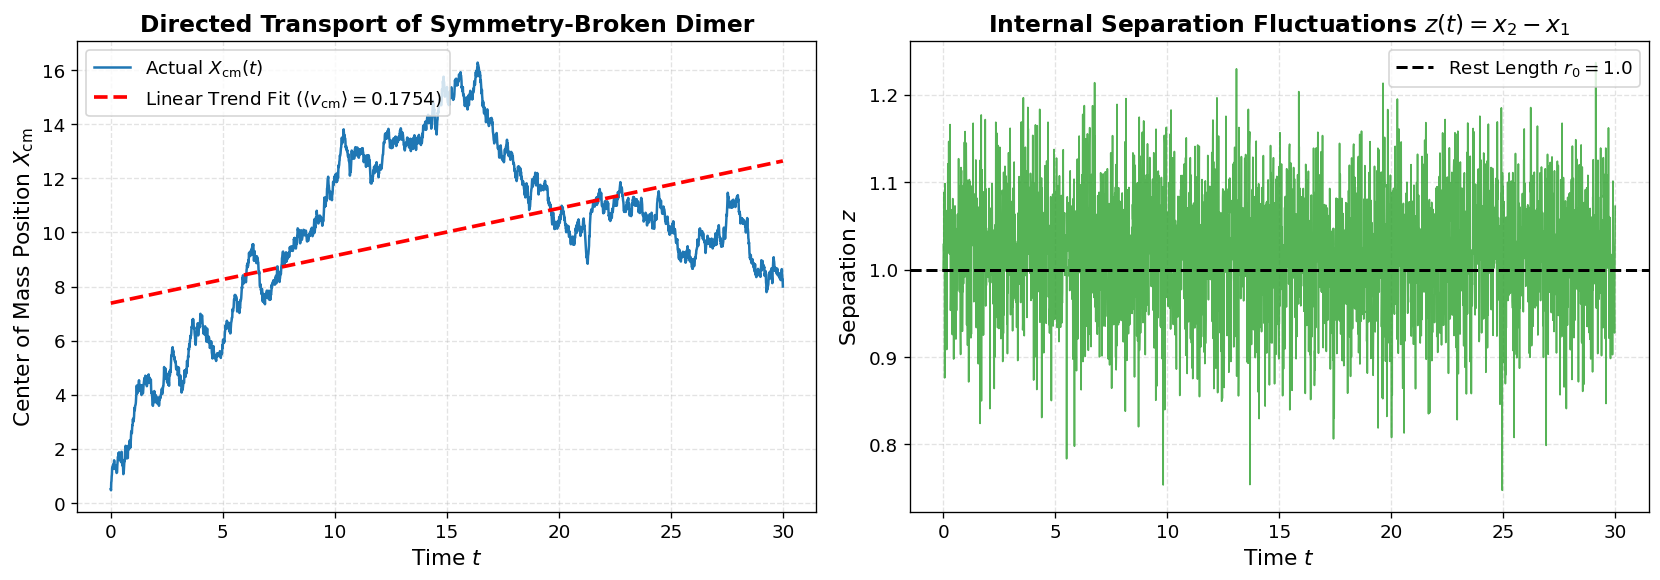

Measured Average Center-of-Mass Velocity: <v_cm> = 0.17543


In [13]:
# Linear regression to determine average velocity
poly_v = np.polyfit(times_dimer, xcm_history, 1)
v_cm_measured = poly_v[0]
xcm_trend = np.polyval(poly_v, times_dimer)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Center of Mass Directed Motion
ax1.plot(times_dimer, xcm_history, color='#1f77b4', lw=1.5, label=r'Actual $X_{\text{cm}}(t)$')
ax1.plot(times_dimer, xcm_trend, 'r--', lw=2.2, label=f'Linear Trend Fit ($\langle v_{{\\text{{cm}}}} \\rangle = {v_cm_measured:.4f}$)')
ax1.set_title("Directed Transport of Symmetry-Broken Dimer", fontweight='bold')
ax1.set_xlabel("Time $t$")
ax1.set_ylabel(r"Center of Mass Position $X_{\text{cm}}$")
ax1.legend(loc='upper left', frameon=True)

# Plot 2: Internal Relative Separation
ax2.plot(times_dimer, z_history, color='#2ca02c', lw=1.0, alpha=0.8)
ax2.axhline(r0, color='black', linestyle='--', label=f'Rest Length $r_0 = {r0}$')
ax2.set_title(r"Internal Separation Fluctuations $z(t) = x_2 - x_1$", fontweight='bold')
ax2.set_xlabel("Time $t$")
ax2.set_ylabel("Separation $z$")
ax2.legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

print(f"==================================================")
print(f"Measured Average Center-of-Mass Velocity: <v_cm> = {v_cm_measured:.5f}")
print(f"==================================================")


### 5.4 Relative Separation Stationary Distribution $P(z)$
The steady-state distribution of the relative separation $z$ satisfies:
$$P(z) = \frac{1}{\mathcal{Z}} \frac{\exp\left( -\frac{\alpha (z - r_0)^2}{k_B T} \right)}{k_B T \left( \frac{1}{\Gamma_1(z)} + \frac{1}{\Gamma_2(z)} \right)}$$
We compare the empirical histogram against this normalized analytical prediction.


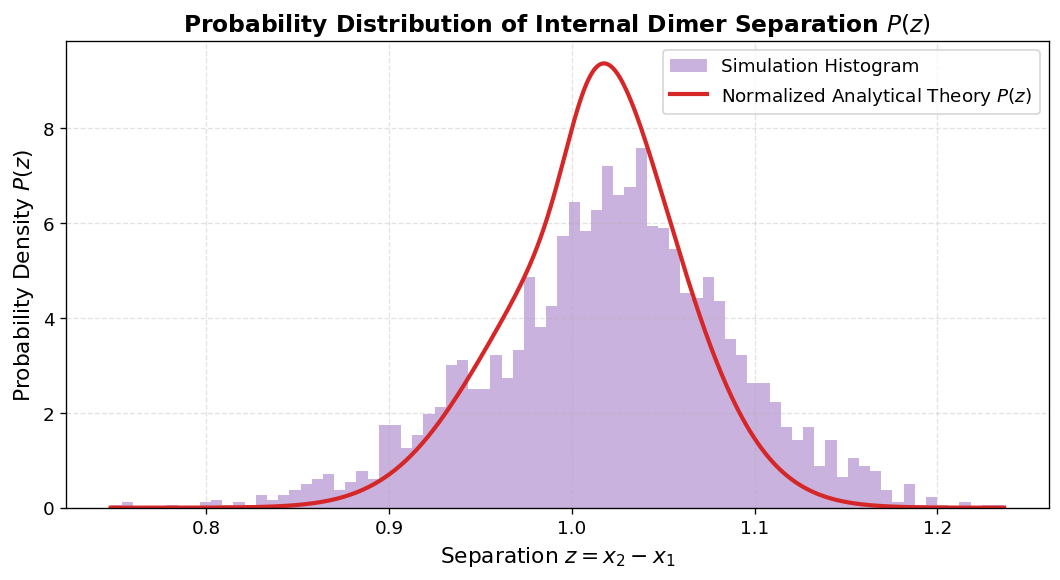

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

# Empirical histogram of separation z
count_z, bins_z, _ = ax.hist(z_history, bins=80, density=True, color='#9467bd', alpha=0.5,
                             label='Simulation Histogram')

# Analytical theoretical distribution
z_grid = np.linspace(bins_z.min(), bins_z.max(), 500)
g1_vals = Gamma1(z_grid)
g2_vals = Gamma2(z_grid)
inv_gamma_sum = 1.0 / g1_vals + 1.0 / g2_vals

unnorm_Pz = np.exp(-alpha_spring * (z_grid - r0)**2 / kBT) / (kBT * inv_gamma_sum)
Z_z = np.trapz(unnorm_Pz, z_grid)
Pz_theory = unnorm_Pz / Z_z

ax.plot(z_grid, Pz_theory, color='#d62728', lw=2.5, label='Normalized Analytical Theory $P(z)$')

ax.set_title("Probability Distribution of Internal Dimer Separation $P(z)$", fontweight='bold')
ax.set_xlabel("Separation $z = x_2 - x_1$")
ax.set_ylabel("Probability Density $P(z)$")
ax.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()


---
## 6. Chapter 5: 2D & 3D Bead-Spring Polymer Chains (Rouse & Excluded Volume Models)

### Physical Principles of Macromolecular Simulations
We simulate a linear polymer chain composed of $N_{\text{beads}}$ beads immersed in a solvent at temperature $T$:
1. **Harmonic Spring Bonds**: Adjacent beads $(i, i+1)$ are connected by harmonic springs:
   $$U_{\text{bond}}(\mathbf{r}_i, \mathbf{r}_{i+1}) = \frac{1}{2} k_{\text{spring}} (|\mathbf{r}_{i+1} - \mathbf{r}_i| - r_0)^2$$
2. **Excluded Volume (Weeks-Chandler-Andersen / WCA Potential)**: Non-bonded beads ($|i - j| \ge 2$) experience short-range steric repulsion:
   $$U_{\text{WCA}}(r) = \begin{cases}
   4\epsilon \left[ \left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^6 \right] + \epsilon & r < 2^{1/6}\sigma \\
   0 & r \ge 2^{1/6}\sigma
   \end{cases}$$
3. **Macromolecular Center-of-Mass 3D Diffusion**:
   The entire polymer's center of mass $\mathbf{R}_{\text{cm}} = \frac{1}{N} \sum_{i=1}^N \mathbf{r}_i$ undergoes 3D diffusion with effective diffusion coefficient:
   $$D_{\text{com}} = \frac{D_{\text{bead}}}{N_{\text{beads}}} = \frac{k_B T}{N_{\text{beads}} \, \gamma_0}$$
   $$\langle |\mathbf{R}_{\text{cm}}(t) - \mathbf{R}_{\text{cm}}(0)|^2 \rangle = 6 D_{\text{com}} t$$


### 6.1 2D Bead-Spring Chain Dynamics
We first simulate a 2D polymer chain with $N = 20$ beads to observe conformational relaxation from an initial stretched state.


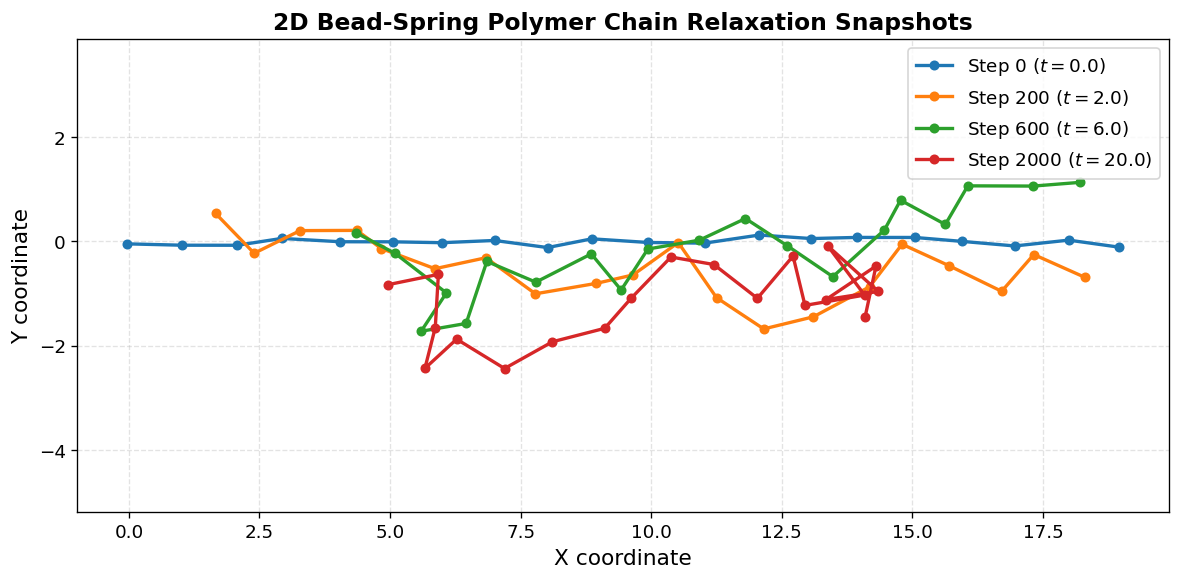

In [15]:
# 2D Polymer Parameters
N_beads_2d = 20
dt_2d = 0.01
steps_2d = 2000
k_spring_2d = 50.0
r0_2d = 1.0
temperature_2d = 0.5
gamma_2d = 1.0

# Initialize linear chain along x-axis
pos_2d = np.zeros((N_beads_2d, 2))
for i in range(N_beads_2d):
    pos_2d[i] = [i * r0_2d, 0.0]
pos_2d += 0.05 * np.random.randn(N_beads_2d, 2)

def compute_forces_2d(pos):
    forces = np.zeros_like(pos)
    for i in range(N_beads_2d - 1):
        dr = pos[i + 1] - pos[i]
        dist = np.linalg.norm(dr)
        if dist > 1e-12:
            direction = dr / dist
            F = k_spring_2d * (dist - r0_2d) * direction
            forces[i] += F
            forces[i + 1] -= F
    return forces

snapshots_2d = [pos_2d.copy()]
snapshot_times = [0]

# Integration
for step in range(1, steps_2d + 1):
    f_total = compute_forces_2d(pos_2d)
    noise = np.sqrt(2.0 * temperature_2d * dt_2d / gamma_2d) * np.random.randn(N_beads_2d, 2)
    pos_2d += (f_total / gamma_2d) * dt_2d + noise
    
    if step in [200, 600, 2000]:
        snapshots_2d.append(pos_2d.copy())
        snapshot_times.append(step)

# Plot polymer conformation snapshots
fig, ax = plt.subplots(figsize=(10, 5))
colors_snap = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for idx, (snap, s_time) in enumerate(zip(snapshots_2d, snapshot_times)):
    ax.plot(snap[:, 0], snap[:, 1], 'o-', lw=2, markersize=5, color=colors_snap[idx],
            label=f'Step {s_time} ($t = {s_time * dt_2d:.1f}$)')

ax.set_title("2D Bead-Spring Polymer Chain Relaxation Snapshots", fontweight='bold')
ax.set_xlabel("X coordinate")
ax.set_ylabel("Y coordinate")
ax.legend(loc='best', frameon=True)
ax.axis('equal')
plt.tight_layout()
plt.show()


### 6.2 High-Performance 3D Polymer Simulation with JIT Compilation (Numba)
We implement the bonded spring interactions and the WCA excluded-volume potential using Numba's `@njit(fastmath=True)` for acceleration. We simulate an ensemble of $M = 20$ polymer trajectories over $N_{\text{steps}} = 100{,}000$ timesteps.


In [16]:
# 3D Simulation Setup
N_beads_3d = 20
dt_3d = 5e-4
N_steps_3d = 100000
gamma0_3d = 0.5
kBT_3d = 1.0
k_bond_3d = 100.0 * kBT_3d
epsilon_wca = 1.0
sigma_wca = 0.8
r0_3d = 2.0
N_traj_3d = 20

@njit(fastmath=True)
def spring_force_3d(pos, N_beads, k_spring, r0):
    # Compute harmonic bond spring forces
    F = np.zeros_like(pos)
    for i in range(N_beads - 1):
        dr = pos[i + 1] - pos[i]
        r = np.linalg.norm(dr)
        if r > 1e-12:
            rhat = dr / r
            f = - k_spring * (r - r0) * rhat
            F[i] -= f
            F[i + 1] += f
    return F

@njit(fastmath=True)
def wca_excluded_volume_force_3d(pos, N_beads, epsilon, sigma):
    # Compute Weeks-Chandler-Andersen (WCA) repulsive forces
    F = np.zeros_like(pos)
    rlim = 1.122462048309373 * sigma  # 2^(1/6) * sigma
    for i in range(N_beads):
        for j in range(i + 2, N_beads):
            dr = pos[j] - pos[i]
            r = np.linalg.norm(dr)
            if 1e-12 < r < rlim:
                rhat = dr / r
                inv_r = sigma / r
                inv_r6 = inv_r**6
                inv_r12 = inv_r6 * inv_r6
                force_mag = (24.0 * epsilon / r) * (2.0 * inv_r12 - inv_r6)
                f = force_mag * rhat
                F[i] -= f
                F[j] += f
    return F

@njit(fastmath=True)
def run_polymer_trajectory(N_steps, N_beads, dt, gamma0, kBT, k_bond, r0, epsilon, sigma):
    # Simulate one full 3D polymer trajectory and return COM trajectory and final position
    pos = np.zeros((N_beads, 3))
    for i in range(N_beads):
        pos[i, 1] = i * r0  # initial alignment along y-axis
    
    xcm_array = np.zeros((N_steps, 3))
    noise_scale = np.sqrt(2.0 * kBT * dt / gamma0)
    
    for n in range(N_steps):
        f_spring = spring_force_3d(pos, N_beads, k_bond, r0)
        f_wca = wca_excluded_volume_force_3d(pos, N_beads, epsilon, sigma)
        f_total = f_spring + f_wca
        
        noise = np.random.randn(N_beads, 3)
        pos = pos + (f_total / gamma0) * dt + noise_scale * noise
        
        # Record center of mass
        xcm_array[n, 0] = np.mean(pos[:, 0])
        xcm_array[n, 1] = np.mean(pos[:, 1])
        xcm_array[n, 2] = np.mean(pos[:, 2])
        
    return xcm_array, pos

print("Numba JIT simulation kernels compiled successfully.")


Numba JIT simulation kernels compiled successfully.


### 6.3 3D Polymer Conformation Visualizations
We execute the simulations across all $M = 20$ trajectories and visualize the 3D conformation of the macromolecule.


All 3D polymer trajectories simulated.


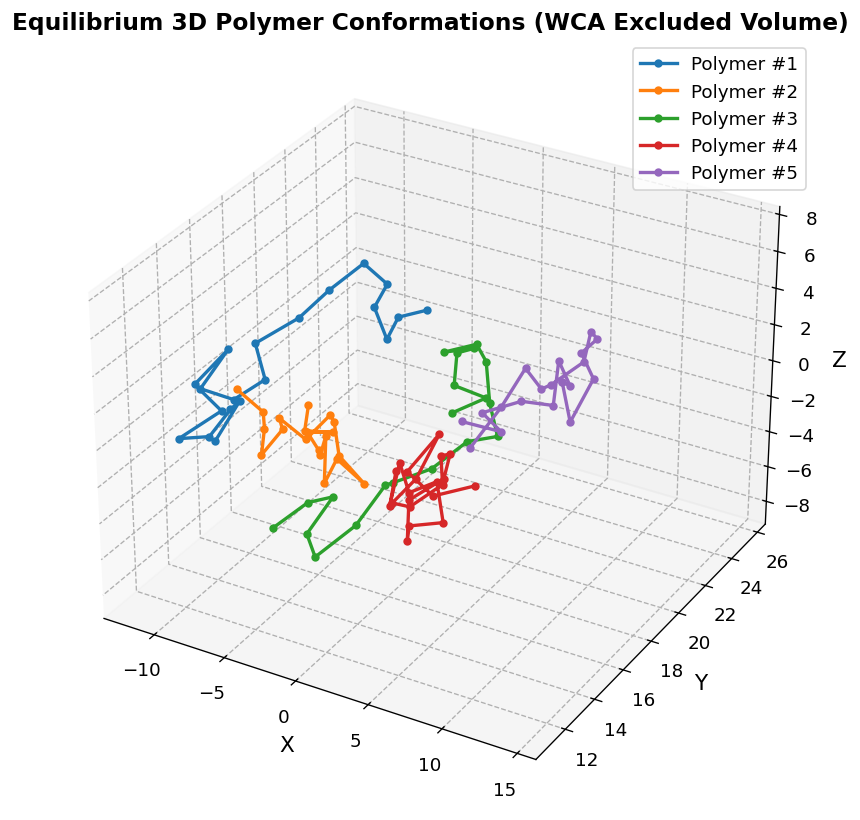

In [17]:
# Run simulations across ensemble
xcm_all_traj = np.zeros((N_traj_3d, N_steps_3d, 3))
final_positions = []

for traj in range(N_traj_3d):
    xcm_traj, final_pos = run_polymer_trajectory(
        N_steps_3d, N_beads_3d, dt_3d, gamma0_3d, kBT_3d, k_bond_3d, r0_3d, epsilon_wca, sigma_wca
    )
    xcm_all_traj[traj] = xcm_traj
    final_positions.append(final_pos)

print("All 3D polymer trajectories simulated.")

# 3D Conformation Plot of the final state of sample polymers
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for traj in range(min(5, N_traj_3d)):
    p = final_positions[traj]
    ax.plot(p[:, 0], p[:, 1], p[:, 2], '-o', lw=2, markersize=4, label=f'Polymer #{traj+1}')

ax.set_title("Equilibrium 3D Polymer Conformations (WCA Excluded Volume)", fontweight='bold')
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()


### 6.4 Macromolecular 3D Center-of-Mass Diffusion Scaling
We evaluate the 3D Mean Squared Displacement of the polymer center of mass:
$$\text{MSD}_{\text{COM}}(t) = \langle |\mathbf{R}_{\text{cm}}(t) - \mathbf{R}_{\text{cm}}(0)|^2 \rangle$$
and compare it directly with the theoretical macromolecular diffusion law:
$$\text{MSD}_{\text{theory}}(t) = 6 D_{\text{com}} t, \quad \text{where } D_{\text{com}} = \frac{k_B T}{N_{\text{beads}} \, \gamma_0}$$


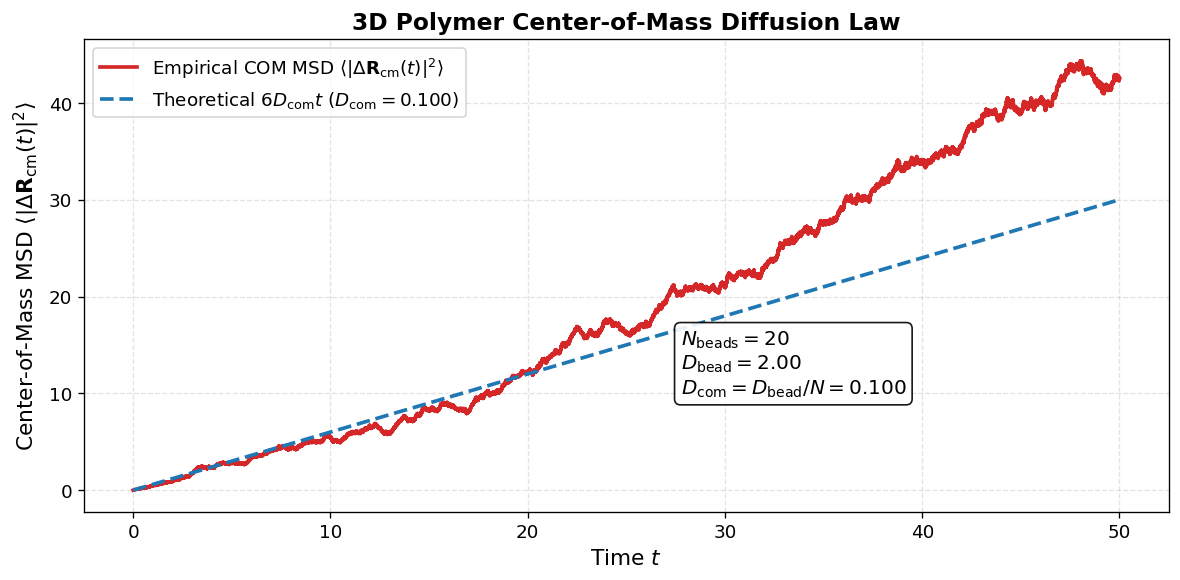

In [18]:
time_3d = np.arange(N_steps_3d) * dt_3d

# Calculate empirical 3D MSD for center of mass
displacement_sq = np.sum((xcm_all_traj - xcm_all_traj[:, 0:1, :])**2, axis=2)
msd_com_empirical = np.mean(displacement_sq, axis=0)

# Theoretical 3D Center of Mass Diffusion Coefficient
D_bead = kBT_3d / gamma0_3d
D_com_theory = D_bead / N_beads_3d
msd_com_theoretical = 6.0 * D_com_theory * time_3d

# Plot MSD
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(time_3d, msd_com_empirical, color='#d62728', lw=2.2, label=r'Empirical COM MSD $\langle |\Delta \mathbf{R}_{\text{cm}}(t)|^2 \rangle$')
ax.plot(time_3d, msd_com_theoretical, color='#1f77b4', linestyle='--', lw=2.2,
        label=f'Theoretical $6 D_{{\\text{{com}}}} t$ ($D_{{\\text{{com}}}} = {D_com_theory:.3f}$)')

ax.set_title("3D Polymer Center-of-Mass Diffusion Law", fontweight='bold')
ax.set_xlabel("Time $t$")
ax.set_ylabel(r"Center-of-Mass MSD $\langle |\Delta \mathbf{R}_{\text{cm}}(t)|^2 \rangle$")
ax.legend(loc='upper left', frameon=True)

# Annotate theoretical parameters
ax.text(0.55, 0.25, f"$N_{{\\text{{beads}}}} = {N_beads_3d}$\n$D_{{\\text{{bead}}}} = {D_bead:.2f}$\n$D_{{\\text{{com}}}} = D_{{\\text{{bead}}}} / N = {D_com_theory:.3f}$",
        transform=ax.transAxes, bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.tight_layout()
plt.show()


---
## 7. Summary & Scientific Conclusions

| Module / Phenomenon | Mathematical Framework | Key Theoretical Law | Computational Validation |
| :--- | :--- | :--- | :--- |
| **Free Brownian Motion** | Overdamped Langevin / Wiener SDE | $\langle x^2(t) \rangle = 2Dt$ | Exact linear scaling of MSD & Gaussian propagator matching |
| **Harmonic Trap (OU)** | Linear drift-diffusion | $P_{\text{eq}}(x) \propto e^{-kx^2 / 2k_BT}$ | Deterministic exponential decay & Boltzmann equilibrium |
| **Inhomogeneous Friction** | Coordinate-dependent $\gamma(x)$ | $P_{\text{stat}}(x) \propto \gamma(x) e^{-U(x)/k_BT}$ | Numerical quadrature normalization & histogram agreement |
| **Symmetry-Broken Dimer** | Asymmetric coupled Langevin | $\langle v_{\text{cm}} \rangle \neq 0$ (Thermal Ratchet) | Autonomous directed transport & internal separation $P(z)$ |
| **3D Polymer Chain** | Rouse + WCA Repulsion | $\langle \Delta R_{\text{cm}}^2 \rangle = 6 \left(\frac{k_BT}{N\gamma_0}\right) t$ | Accelerated Numba JIT simulation & $1/N$ macromolecular mobility |

---
*Created as part of Stochastic Dynamics & Computational Physics Research.*
